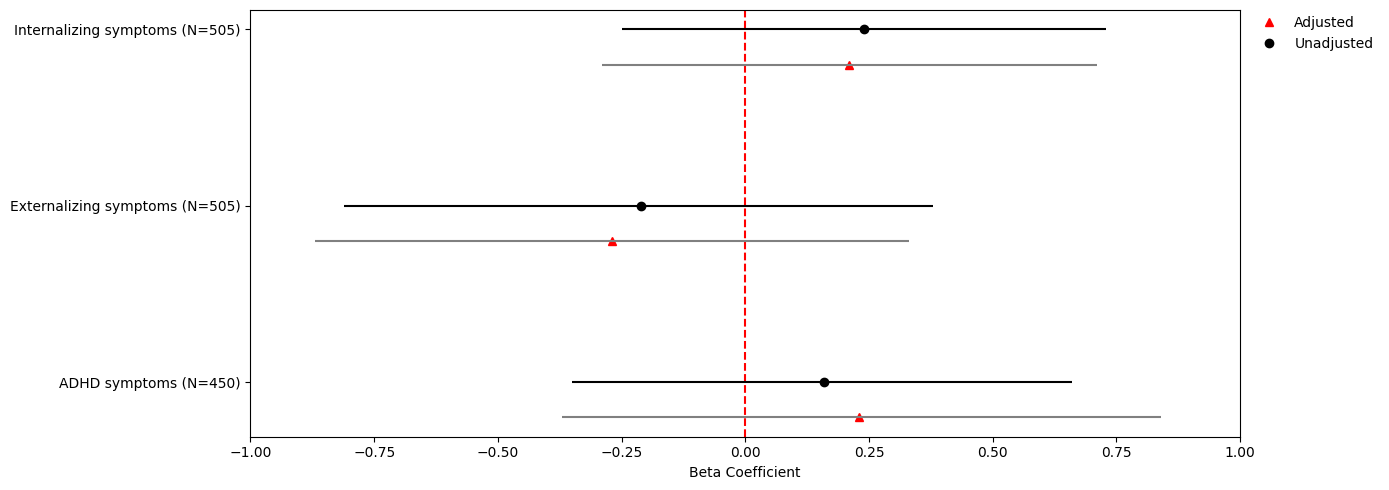

In [7]:
# This is the code for Unadjusted and adjusted associations between malaria at any time in pregnancy and children’s internalizing and externalizing symptoms (N=505) and ADHD symptoms (N=450) at 6 years

import matplotlib.pyplot as plt
import numpy as np

# Ordered: ADHD, Externalizing, Internalizing
outcomes = ['ADHD symptoms (N=450)', 'Externalizing symptoms (N=505)', 'Internalizing symptoms (N=505)']
y_pos = np.arange(len(outcomes))

# Coefficients and CI
beta_unadjusted = [0.16, -0.21, 0.24]
ci_unadjusted = [(-0.35, 0.66), (-0.81, 0.38), (-0.25, 0.73)]
beta_adjusted = [0.23, -0.27, 0.21]
ci_adjusted = [(-0.37, 0.84), (-0.87, 0.33), (-0.29, 0.71)]

# Create plot
fig, ax = plt.subplots(figsize=(14, 5))

# Vertical line at 0
ax.axvline(x=0, color='red', linestyle='--')

# Adjusted (triangles + gray CI)
for i in range(len(outcomes)):
    ax.plot(beta_adjusted[i], y_pos[i] - 0.2, 'r^', label='Adjusted' if i == 0 else "")
    ax.hlines(y=y_pos[i] - 0.2, xmin=ci_adjusted[i][0], xmax=ci_adjusted[i][1], color='gray')

# Unadjusted (circles + black CI)
for i in range(len(outcomes)):
    ax.plot(beta_unadjusted[i], y_pos[i], 'ko', label='Unadjusted' if i == 0 else "")
    ax.hlines(y=y_pos[i], xmin=ci_unadjusted[i][0], xmax=ci_unadjusted[i][1], color='black')

# Axis formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(outcomes)
ax.set_xlabel('Beta Coefficient')
ax.set_xlim(-1, 1)

# Legend outside top-right
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.01, 1),  # nudges it just right of the plot
    borderaxespad=0.,
    frameon=False  # optional: make it cleaner
)

# Layout
plt.tight_layout()
plt.show()


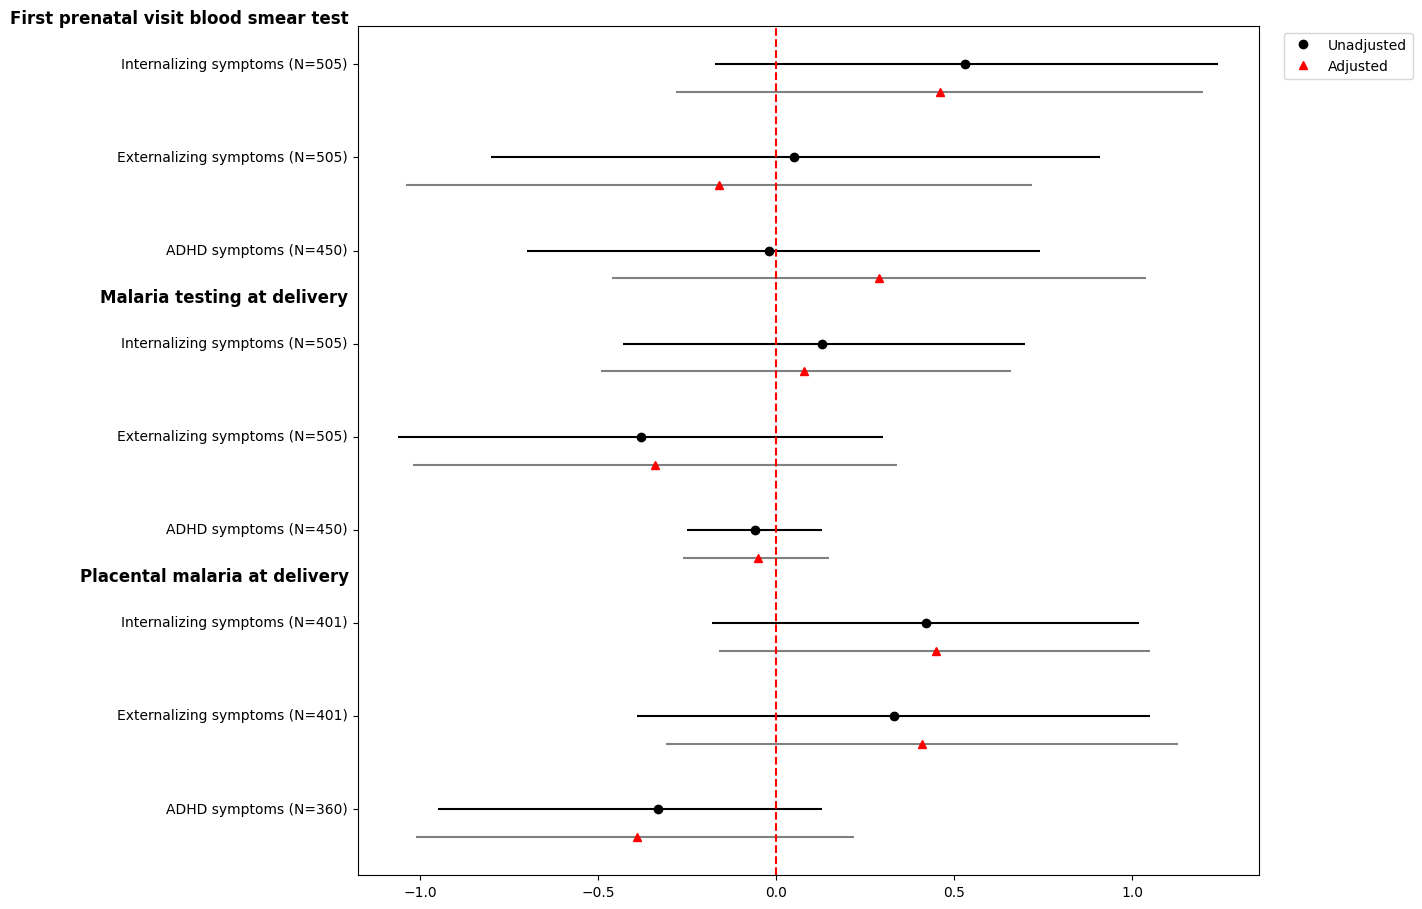

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Exposure groups
exposures = [
    "First prenatal visit blood smear test",
    "Malaria testing at delivery",
    "Placental malaria at delivery"
]

# Outcomes
outcomes = [
    "Internalizing symptoms",
    "Externalizing symptoms",
    "ADHD symptoms"
]

# Sample sizes (per outcome x exposure)
sample_sizes = [
    [505, 505, 401],  # Internalizing
    [505, 505, 401],  # Externalizing
    [450, 450, 360]   # ADHD
]

# Updated beta values and 95% CIs
betas_unadj = [0.53, 0.05, -0.02,  # First prenatal visit (Unadjusted)
               0.13, -0.38, -0.06,  # Birth (Unadjusted)
               0.42, 0.33, -0.33]   # Placental malaria (Unadjusted)

betas_adj = [0.46, -0.16, 0.29,  # First prenatal visit (Adjusted)
             0.08, -0.34, -0.05,  # Birth (Adjusted)
             0.45, 0.41, -0.39]   # Placental malaria (Adjusted)

cis_unadj = [(-0.17, 1.24), (-0.80, 0.91), (-0.70, 0.74),  # First prenatal visit
             (-0.43, 0.70), (-1.06, 0.30), (-0.25, 0.13),  # Birth
             (-0.18, 1.02), (-0.39, 1.05), (-0.95, 0.13)]  # Placental malaria

cis_adj = [(-0.28, 1.20), (-1.04, 0.72), (-0.46, 1.04),  # First prenatal visit
           (-0.49, 0.66), (-1.02, 0.34), (-0.26, 0.15),  # Birth
           (-0.16, 1.05), (-0.31, 1.13), (-1.01, 0.22)]  # Placental malaria

# Setup
n_exposures = len(exposures)
n_outcomes = len(outcomes)
total_rows = n_exposures * n_outcomes

fig_height = total_rows * 0.8 + 2  # Slightly taller to accommodate labels
fig, ax = plt.subplots(figsize=(18, fig_height))  # Wide format for CI fitting

y_pos = []
yticks = []

# Main plotting loop
for i in range(n_exposures):
    for j in range(n_outcomes):
        index = i * n_outcomes + j
        y = total_rows - index - 1
        y_pos.append(y)

        # Labels
        outcome_label = f"{outcomes[j]} (N={sample_sizes[j][i]})"
        yticks.append(outcome_label)

        # Plot unadjusted
        ax.hlines(y=y, xmin=cis_unadj[index][0], xmax=cis_unadj[index][1], color='black')
        ax.plot(betas_unadj[index], y, 'ko', label='Unadjusted' if index == 0 else "")

        # Plot adjusted
        ax.hlines(y=y - 0.3, xmin=cis_adj[index][0], xmax=cis_adj[index][1], color='gray')
        ax.plot(betas_adj[index], y - 0.3, 'r^', label='Adjusted' if index == 0 else "")

# Add tick marks on the left side
ax.set_yticks(y_pos)
ax.set_yticklabels(yticks, va='center', ha='right', fontsize=10)

# Add reference line at 0
ax.axvline(x=0, color='red', linestyle='--')

# Add bold exposure group titles directly above their respective outcomes
for i in range(n_exposures):
    y_title = y_pos[i * n_outcomes] + 0.4  # Adjust spacing for better alignment
    ax.text(-1.2, y_title, exposures[i], fontweight='bold', va='bottom', ha='right', fontsize=12)

# Adjust legend position
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(left=0.4)  # Make room for tick labels
plt.show()


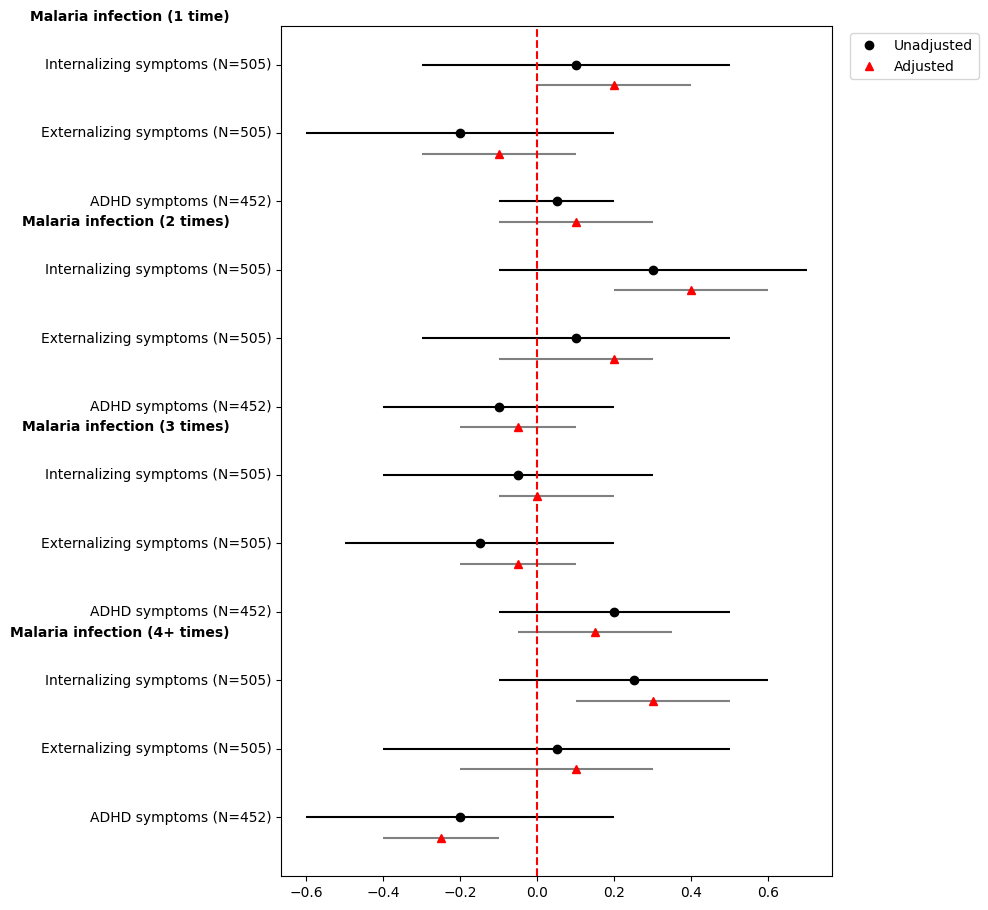

In [8]:
import matplotlib.pyplot as plt

# Exposure groups (Malaria infection frequency)
exposures = [
    "Malaria infection (1 time)",
    "Malaria infection (2 times)",
    "Malaria infection (3 times)",
    "Malaria infection (4+ times)"
]

# Outcomes
outcomes = [
    "Internalizing symptoms",
    "Externalizing symptoms",
    "ADHD symptoms"
]

# Sample sizes
sample_sizes = [
    [505, 505, 452],  # Group 1 (1 time)
    [505, 505, 452],  # Group 2 (2 times)
    [505, 505, 452],  # Group 3 (3 times)
    [505, 505, 452],  # Group 4 (4+ times)
]

# Beta values and confidence intervals
betas_unadj = [0.1, -0.2, 0.05,   # Group 1 (Unadjusted)
               0.3, 0.1, -0.1,    # Group 2 (Unadjusted)
               -0.05, -0.15, 0.2, # Group 3 (Unadjusted)
               0.25, 0.05, -0.2]  # Group 4 (Unadjusted)

cis_unadj = [(-0.3, 0.5), (-0.6, 0.2), (-0.1, 0.2),    # Group 1
             (-0.1, 0.7), (-0.3, 0.5), (-0.4, 0.2),    # Group 2
             (-0.4, 0.3), (-0.5, 0.2), (-0.1, 0.5),    # Group 3
             (-0.1, 0.6), (-0.4, 0.5), (-0.6, 0.2)]    # Group 4

betas_adj = [0.2, -0.1, 0.1,    # Group 1 (Adjusted)
             0.4, 0.2, -0.05,   # Group 2 (Adjusted)
             0.0, -0.05, 0.15,  # Group 3 (Adjusted)
             0.3, 0.1, -0.25]   # Group 4 (Adjusted)

cis_adj = [(0.0, 0.4), (-0.3, 0.1), (-0.1, 0.3),    # Group 1
           (0.2, 0.6), (-0.1, 0.3), (-0.2, 0.1),    # Group 2
           (-0.1, 0.2), (-0.2, 0.1), (-0.05, 0.35), # Group 3
           (0.1, 0.5), (-0.2, 0.3), (-0.4, -0.1)]   # Group 4

# Setup for plotting
n_exposures = len(exposures)
n_outcomes = len(outcomes)
total_rows = n_exposures * n_outcomes

fig_height = total_rows * 0.6 + 2
fig, ax = plt.subplots(figsize=(12, fig_height))

y_pos = []
yticks = []

# Plotting loop
for i in range(n_exposures):
    for j in range(n_outcomes):
        index = i * n_outcomes + j
        y = total_rows - index - 1
        y_pos.append(y)

        # Labels
        outcome_label = f"{outcomes[j]} (N={sample_sizes[i][j]})"
        yticks.append(outcome_label)

        # Plot unadjusted values
        ax.hlines(y=y, xmin=cis_unadj[index][0], xmax=cis_unadj[index][1], color='black')
        ax.plot(betas_unadj[index], y, 'ko', label='Unadjusted' if index == 0 else "")

        # Plot adjusted values
        ax.hlines(y=y - 0.3, xmin=cis_adj[index][0], xmax=cis_adj[index][1], color='gray')
        ax.plot(betas_adj[index], y - 0.3, 'r^', label='Adjusted' if index == 0 else "")

# Adjust y-axis
ax.set_yticks(y_pos)
ax.set_yticklabels(yticks, va='center', ha='right', fontsize=10)

# Add reference line at 0
ax.axvline(x=0, color='red', linestyle='--')

# Add bold titles for exposure groups
for i in range(n_exposures):
    y_title = y_pos[i * n_outcomes] + 0.6  # Adjust spacing
    ax.text(-0.8, y_title, exposures[i], fontweight='bold', va='bottom', ha='right')

# Legend
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(left=0.4)  # Adjust for long labels
plt.show()


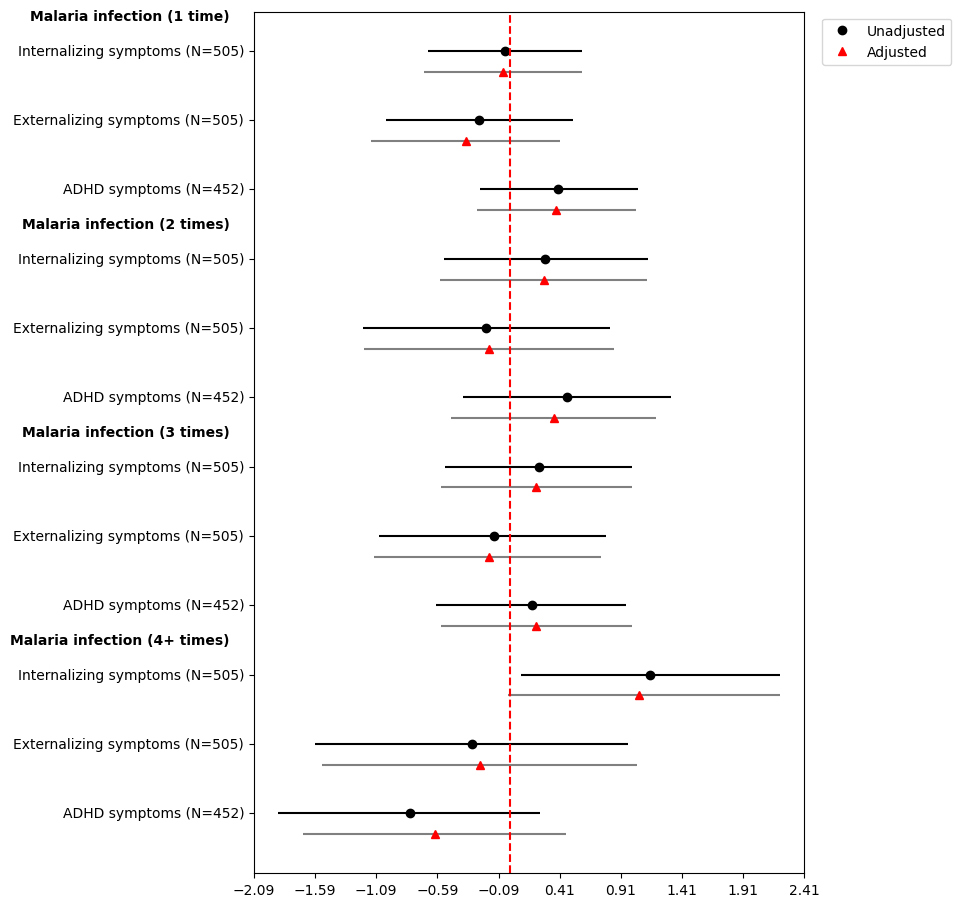

In [13]:
import matplotlib.pyplot as plt

# Exposure groups (Malaria infection frequency)
exposures = [
    "Malaria infection (1 time)",
    "Malaria infection (2 times)",
    "Malaria infection (3 times)",
    "Malaria infection (4+ times)"
]

# Outcomes
outcomes = [
    "Internalizing symptoms",
    "Externalizing symptoms",
    "ADHD symptoms"
]

# Sample sizes (unchanged)
sample_sizes = [
    [505, 505, 452],  # Group 1 (1 time)
    [505, 505, 452],  # Group 2 (2 times)
    [505, 505, 452],  # Group 3 (3 times)
    [505, 505, 452],  # Group 4 (4+ times)
]

# Updated beta values and confidence intervals (Unadjusted)
betas_unadj = [-0.04, -0.25, 0.40,
               0.29, -0.19, 0.47,
               0.24, -0.13, 0.18,
               1.15, -0.31, -0.81]

cis_unadj = [(-0.67, 0.59), (-1.01, 0.52), (-0.24, 1.05),
             (-0.54, 1.13), (-1.20, 0.82), (-0.38, 1.32),
             (-0.53, 1.00), (-1.07, 0.79), (-0.60, 0.95),
             (0.09, 2.21), (-1.59, 0.97), (-1.89, 0.25)]

# Updated beta values and confidence intervals (Adjusted)
betas_adj = [-0.05, -0.36, 0.38,
             0.28, -0.17, 0.36,
             0.22, -0.17, 0.22,
             1.06, -0.24, -0.61]

cis_adj = [(-0.70, 0.59), (-1.13, 0.41), (-0.27, 1.03),
           (-0.57, 1.12), (-1.19, 0.85), (-0.48, 1.20),
           (-0.56, 1.00), (-1.11, 0.75), (-0.56, 1.00),
           (-0.01, 2.21), (-1.53, 1.04), (-1.69, 0.46)]

# Function to generate float ranges
def frange(start, stop, step):
    while start <= stop:
        yield round(start, 2)
        start += step

# Setup for plotting
n_exposures = len(exposures)
n_outcomes = len(outcomes)
total_rows = n_exposures * n_outcomes

fig_height = total_rows * 0.6 + 2
fig, ax = plt.subplots(figsize=(12, fig_height))

y_pos = []
yticks = []

# Plotting loop
for i in range(n_exposures):
    for j in range(n_outcomes):
        index = i * n_outcomes + j
        y = total_rows - index - 1
        y_pos.append(y)

        # Labels
        outcome_label = f"{outcomes[j]} (N={sample_sizes[i][j]})"
        yticks.append(outcome_label)

        # Plot unadjusted values
        ax.hlines(y=y, xmin=cis_unadj[index][0], xmax=cis_unadj[index][1], color='black')
        ax.plot(betas_unadj[index], y, 'ko', label='Unadjusted' if index == 0 else "")

        # Plot adjusted values
        ax.hlines(y=y - 0.3, xmin=cis_adj[index][0], xmax=cis_adj[index][1], color='gray')
        ax.plot(betas_adj[index], y - 0.3, 'r^', label='Adjusted' if index == 0 else "")

# Adjust y-axis
ax.set_yticks(y_pos)
ax.set_yticklabels(yticks, va='center', ha='right', fontsize=10)

# Add reference line at 0
ax.axvline(x=0, color='red', linestyle='--')

# Dynamically set x-axis ticks and limits (fewer ticks)
x_min = min([ci[0] for ci in cis_unadj + cis_adj]) - 0.2
x_max = max([ci[1] for ci in cis_unadj + cis_adj]) + 0.2
ax.set_xlim(x_min, x_max)
ax.set_xticks(list(frange(x_min, x_max, 0.5)))

# Slightly lowered bold exposure group labels
for i in range(n_exposures):
    y_title = y_pos[i * n_outcomes] + 0.4  # lowered from 0.6 to 0.4
    ax.text(x_min - 0.2, y_title, exposures[i], fontweight='bold', va='bottom', ha='right')

# Legend
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(left=0.4)  # Adjust for long labels
plt.show()
